In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [156]:
w_inflation = pd.read_csv("./data/queries/wellbeing - inflation - unemployement.csv")
gdp_w = pd.read_csv("./data/queries/GDP in relation to wellbeing.csv")
avg_w_per_country = pd.read_csv("./data/queries/average wellbeing score x country.csv")
top_three_countries = pd.read_csv("./data/queries/top-3-countries-per-year.csv")
variance = pd.read_csv("./data/queries/variance within countries.csv")
w_country_year = pd.read_csv("./data/queries/wellbeing score x country x year.csv")
w_year = pd.read_csv("./data/queries/wellbeing x year.csv")

In [133]:
w_year.head()

,country_id,year,wellbeing_score
0,20,2005,4.63
1,7,2005,5.56
2,8,2005,4.98
3,19,2005,3.05
4,4,2005,6.84


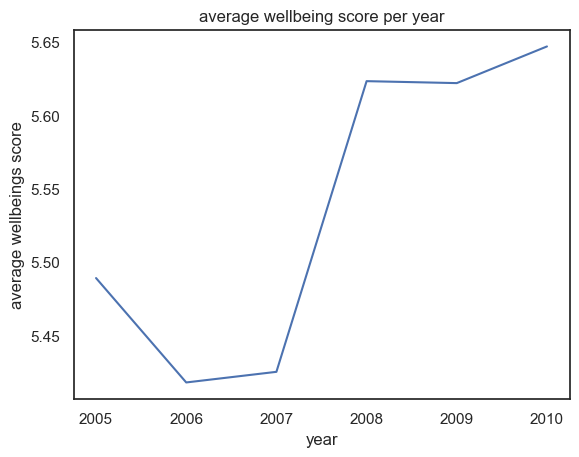

In [134]:
w_year.groupby("year")["wellbeing_score"].mean().plot()
plt.title("average wellbeing score per year")
plt.xlabel("year")
plt.ylabel("average wellbeings score")
plt.show()


In [135]:
w_country_year.head()

,country_name,year,wellbeing_score
0,Australia,2005,5.43
1,Australia,2006,6.03
2,Australia,2007,5.60
3,Australia,2008,5.87
4,Australia,2009,5.18


In [136]:
w_country_year["country_name"].unique()

array(['Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany',
       'India', 'South Africa', 'United Kingdom', 'United States'],
      dtype=object)

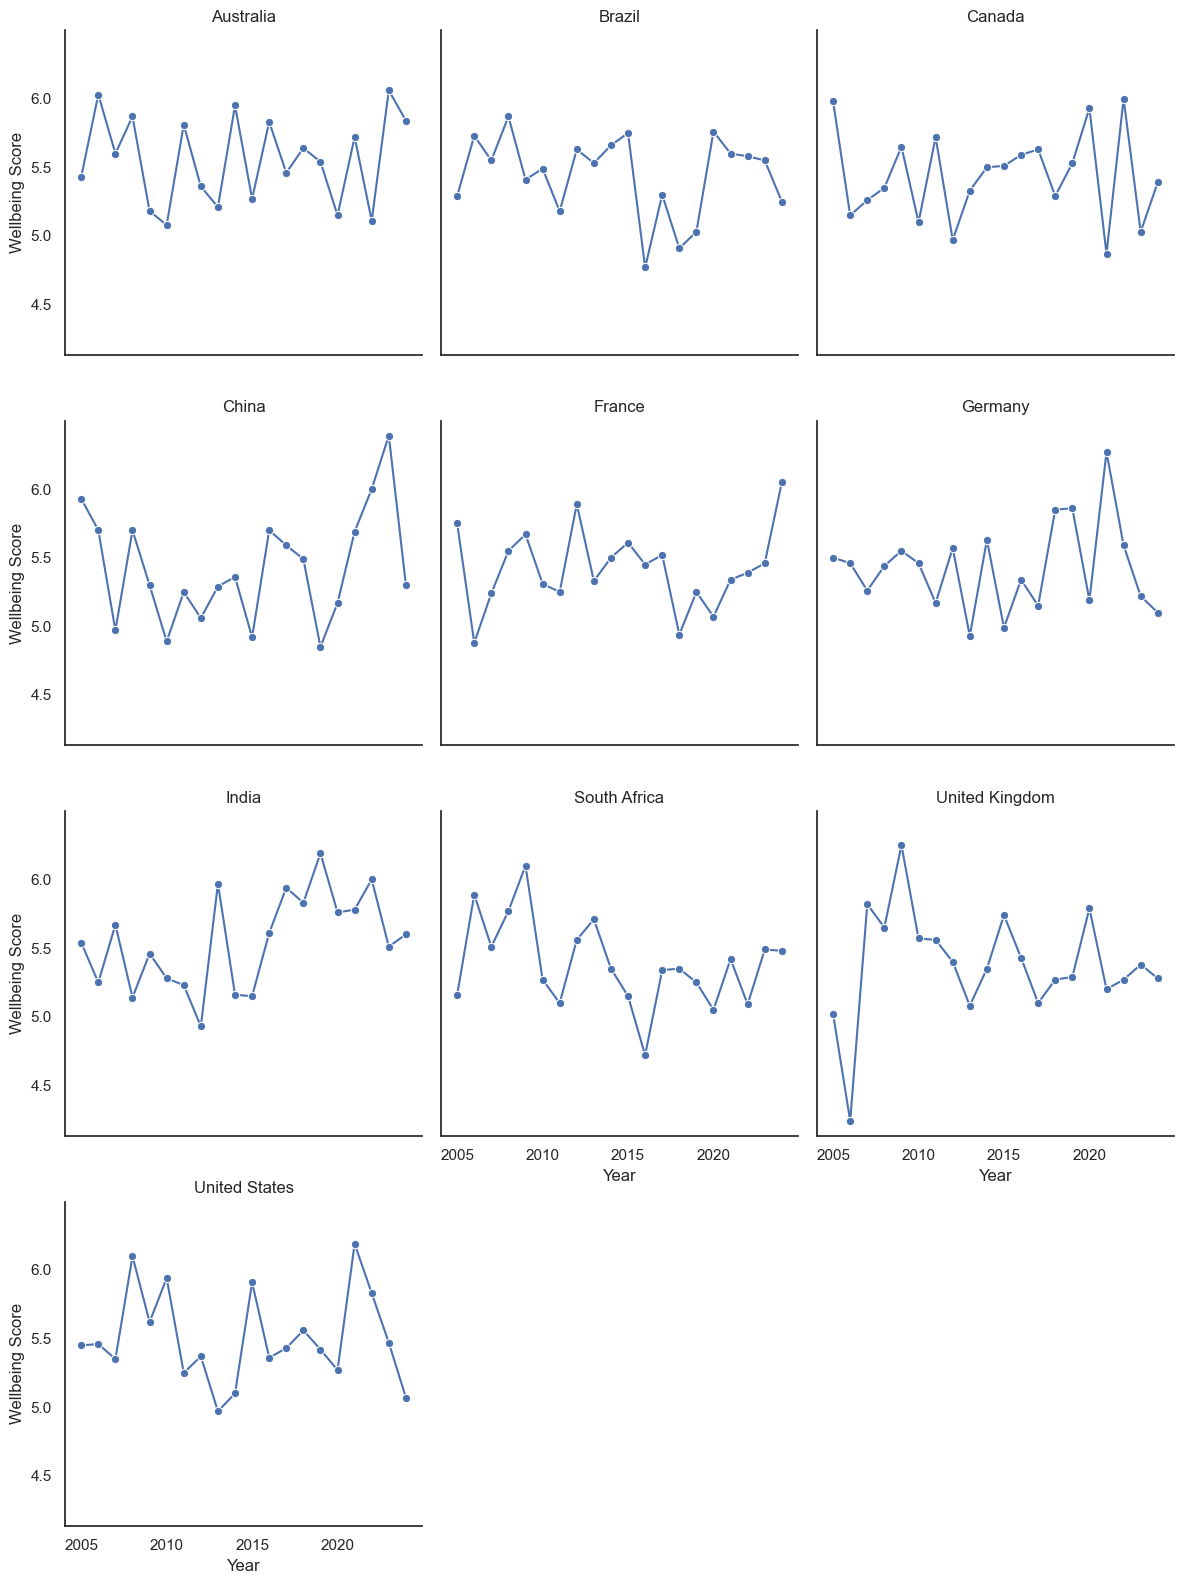

In [137]:
sns.set_theme(style="white")

g = sns.FacetGrid(
    w_country_year,
    col="country_name",
    col_wrap=3,
    height=4,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="year",
    y="wellbeing_score",
    marker="o"
)

g.set_axis_labels("Year", "Wellbeing Score")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

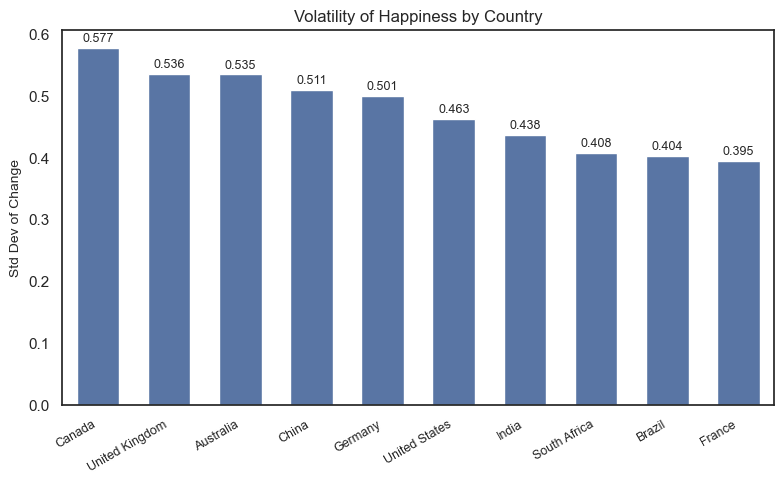

In [149]:

sns.set_theme(style="white")

# sort (already done but safe)
df_plot = volatility.sort_values("change_happiness", ascending=False)

plt.figure(figsize=(8,5))  # smaller = better fit

ax = sns.barplot(
    data=df_plot,
    x="country_name",
    y="change_happiness",
    width=0.6   # slimmer bars
)

# labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=9)

# titles and labels (balanced sizes)
plt.title("Volatility of Happiness by Country", fontsize=12)
plt.xlabel("")
plt.ylabel("Std Dev of Change", fontsize=10)

# rotate labels slightly less
plt.xticks(rotation=30, ha="right", fontsize=9)

# tighten layout
plt.tight_layout()

plt.show()

In [77]:
#Standard deviation (classic volatility measure)
#High std → unstable wellbeing
#Low std → stable country

In [145]:
w_country_year["yearly_change"] = w_country_year.groupby("country_name")["wellbeing_score"].diff()

extremes = w_country_year.groupby("country_name")["yearly_change"].agg(["max", "min"]).reset_index()

extremes

,country_name,max,min
0,Australia,0.95,-0.69
1,Brazil,0.73,-0.98
2,Canada,1.13,-1.06
3,China,0.78,-1.09
4,France,0.64,-0.87
5,Germany,1.08,-0.68
6,India,1.04,-0.81
7,South Africa,0.73,-0.83
8,United Kingdom,1.58,-0.78
9,United States,0.92,-0.69


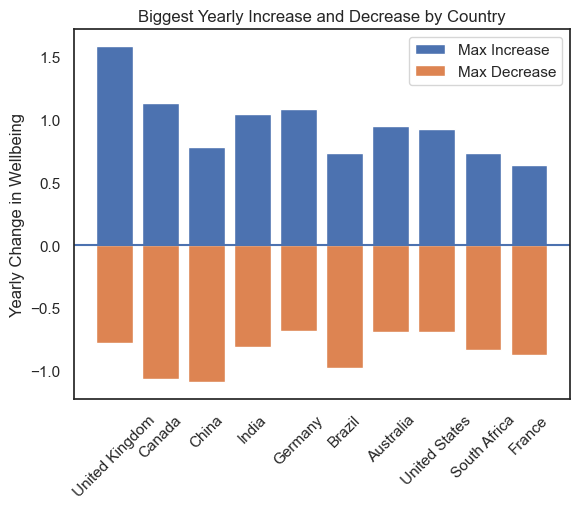

In [150]:
extremes["swing"] = extremes["max"] - extremes["min"]
extremes = extremes.sort_values("swing", ascending=False)

x = np.arange(len(extremes))

plt.figure()

plt.bar(x, extremes["max"], label="Max Increase")
plt.bar(x, extremes["min"], label="Max Decrease")

plt.axhline(0)  # important baseline

plt.xticks(x, extremes["country_name"], rotation=45)
plt.ylabel("Yearly Change in Wellbeing")
plt.title("Biggest Yearly Increase and Decrease by Country")
plt.legend()

plt.show()

In [ ]:
#max = biggest improvement
#min = biggest decline

In [160]:
w_inflation.head()

,country_name,year,wellbeing_score,inflation_rate_pct,unemployment_rate_pct
263,Australia,2010,7.48,2.8,5.2
288,Australia,2010,7.45,2.8,5.2
466,Australia,2010,7.10,2.8,5.2
658,Australia,2010,6.74,2.8,5.2
930,Australia,2010,6.23,2.8,5.2


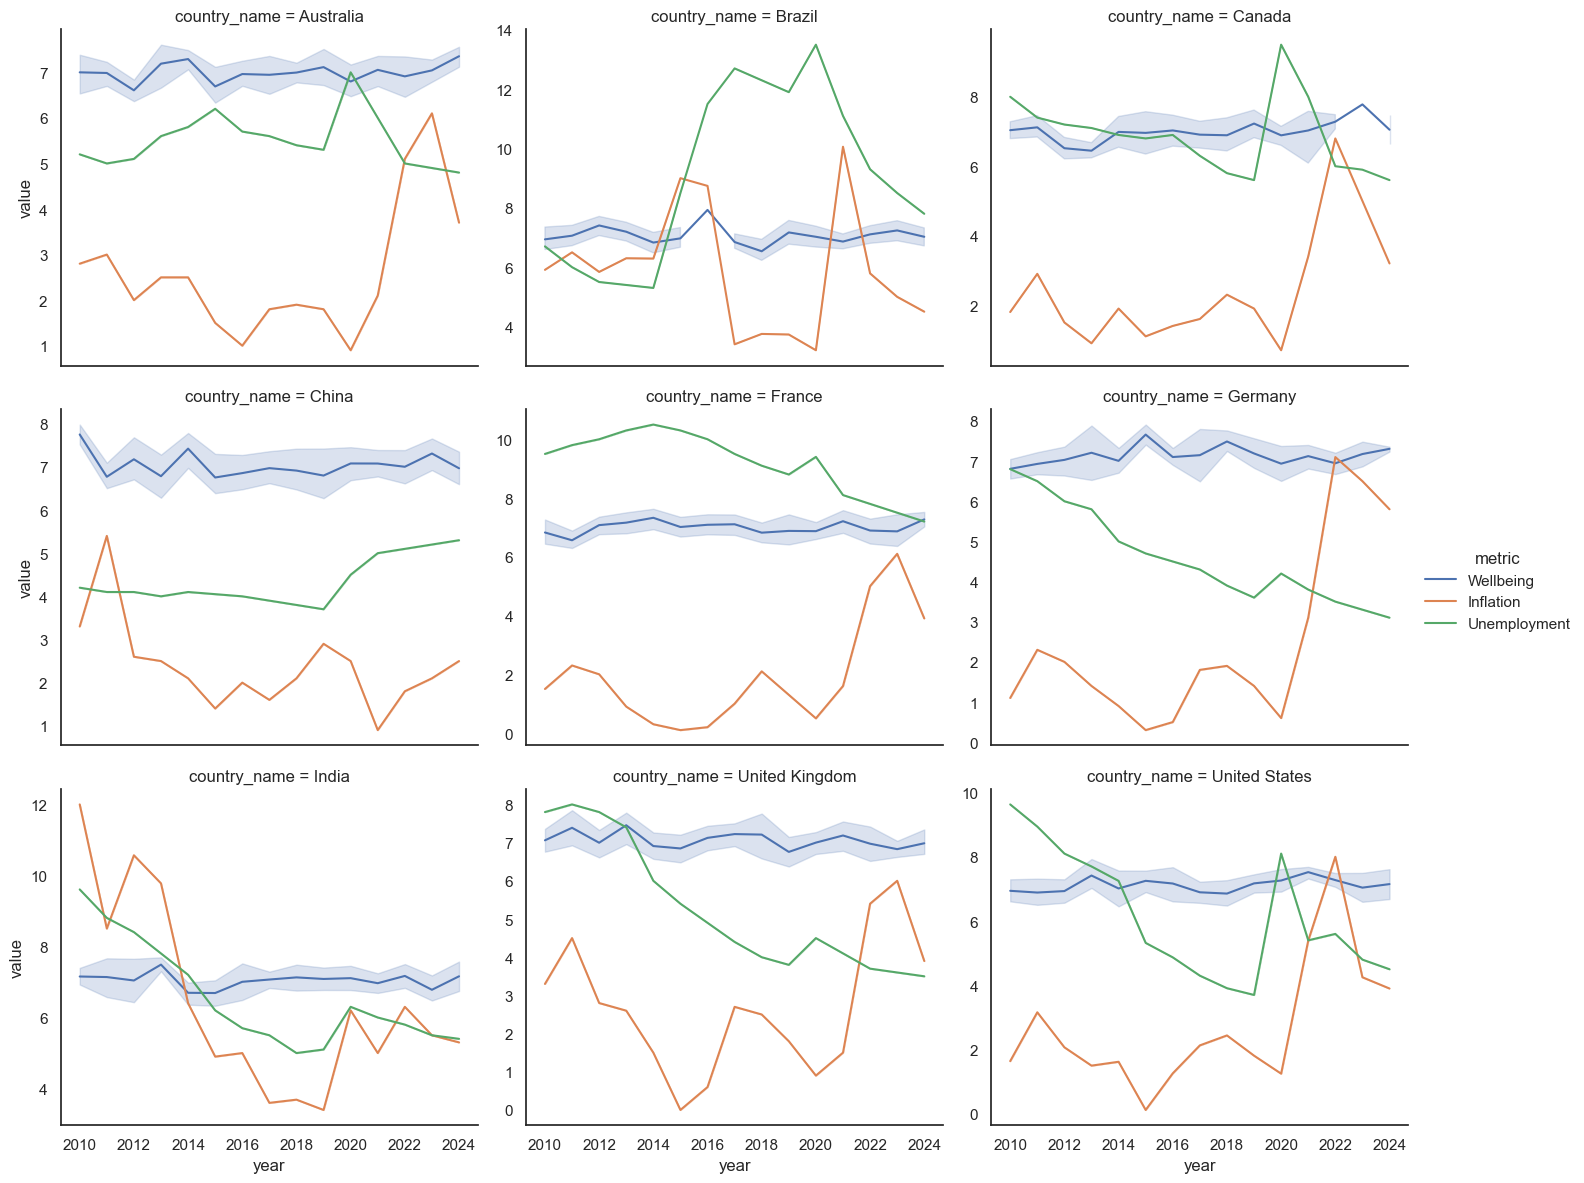

In [159]:
inflation = sns.relplot(
    data=df_long,
    x="year",
    y="value",
    hue="metric",
    kind="line",
    col="country_name",
    col_wrap=3,
    height=4,
    aspect=1.2,
    facet_kws={"sharey": False}
)

# move existing legend (don’t recreate it!)
sns.move_legend(g, "center right", bbox_to_anchor=(1.05, 0.5))

In [164]:
gdp_w["country_name"].unique()

array(['Australia', 'Brazil', 'Canada', 'China'], dtype=object)

In [165]:
table = (
    gdp_w.groupby("country_name")
    .agg(
        avg_wellbeing=("wellbeing_score", "mean"),
        avg_gdp=("gdp_per_capita", "mean"),
        min_wellbeing=("wellbeing_score", "min"),
        max_wellbeing=("wellbeing_score", "max")
    )
    .reset_index()
    .sort_values("avg_wellbeing", ascending=False)
    .round(2)
)

table

,country_name,avg_wellbeing,avg_gdp,min_wellbeing,max_wellbeing
0,Australia,5.54,1665.85,3.04,7.96
2,Canada,5.47,1848.78,3.01,8.00
1,Brazil,5.42,2260.03,3.00,7.98
3,China,5.18,7461.17,3.04,7.98
